<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 20px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội và ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  THƯƠNG HIỆU & HỆ SINH THÁI GIAN HÀNG
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [ ]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [ ]:
# Nạp dữ liệu 
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# Khôi phục Categorical ordered cho price_segment sau khi đọc CSV
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# Tập con theo origin
df_vn = df[df['origin_class'] == 'Trong nước'].copy()
df_nn = df[df['origin_class'] == 'Ngoài nước'].copy()

# Kiểm tra
print(f'Tổng sản phẩm  : {len(df):,}')
print(f'  Trong nước   : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'  Ngoài nước   : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'Số danh mục    : {df["category"].nunique()}')
print(f'Khoảng giá     : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')
print()
df.head(3)

df

Tổng sản phẩm  : 7,266
  Trong nước   : 2,340 (32.2%)
  Ngoài nước   : 4,926 (67.8%)
Số thương hiệu : 960
Số danh mục    : 30
Khoảng giá     : 10,000 – 18,000,000 VNĐ



,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class,origin_normalized,...,rating_tier,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate
0,277375309,Sữa rửa mặt Hada Labo chống lão hóa Premium Cl...,Sữa rửa mặt Hada Labo chống lão hóa Premium Cl...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,Chưa có đánh giá,3286000,True,1,True,0,1,Còn hàng,False,False
1,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,Cao (≥ 4.5),2004500,True,1,True,0,1,Còn hàng,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,Cao (≥ 4.5),799200,True,1,True,0,1,Còn hàng,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,Cao (≥ 4.5),1116000,True,1,True,0,1,Còn hàng,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",Oxy,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,Cao (≥ 4.5),4172000,True,1,True,0,1,Còn hàng,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7261,181806537,Xịt Mọc Tóc Perfect Hair Peptide 50ml Giúp Mọc...,"Xịt Mọc Tóc Perfect Hair Peptide Giúp Mọc Tóc,...",Oem,Beauty Tokyo,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Nhật Bản,...,Chưa có đánh giá,0,False,0,False,0,1,Còn hàng,False,False
7262,77673658,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,Forcolour,Mỹ Phẩm Auth 68,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Trung Quốc,...,Cao (≥ 4.5),8050000,True,1,True,1,1,Còn hàng,False,False
7263,41369694,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,Heavening,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,Chưa có đánh giá,0,True,1,True,1,1,Còn hàng,False,False
7264,41356968,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavenin...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,Heavening,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,Chưa có đánh giá,0,True,1,True,1,1,Còn hàng,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** So sánh tỉ lệ gian hàng chính hãng (Official Store) giữa nội và ngoại dựa trên bộ dữ liệu từ tháng 3/2026 để đánh giá mức độ chuyên nghiệp và uy tín mà các thương hiệu đang xây dựng trên Tiki.
### **2.1.1. Lí do chọn mục tiêu**

Chỉ số Official Store không đơn thuần là một cái nhãn, mà là thước đo của sự chuyên nghiệp, uy tín và khả năng bảo chứng niềm tin. Việc so sánh giúp xác định các thương hiệu Việt đã chú trọng xây dựng hình ảnh bài bản trên sàn TMĐT hay vẫn đang dừng lại ở các hộ kinh doanh nhỏ lẻ so với các tập đoàn quốc tế.

- Đối với *chủ doanh nghiệp mỹ phẩm*: Cần biết vị thế của mình để quyết định đầu tư vào hệ thống gian hàng chính hãng nhằm tăng tỉ lệ chuyển đổi.

- Đối với *sàn thương mại điện tử (Tiki)*: Hiểu được mức độ trưởng thành của các thương hiệu nội địa để có chính sách hỗ trợ, thúc đẩy doanh nghiệp Việt lên Mall, giúp thị trường mỹ phẩm Việt tăng trưởng trên thương trường quốc tế.

- Đối với *người tiêu dùng*: Giúp họ nhận diện được phân khúc nào (Nội hay Ngoại) đang cung cấp sự bảo chứng an toàn cao hơn.

Giá trị thực tiễn: Giúp xác định liệu thị trường mỹ phẩm Việt đang cạnh tranh bằng uy tín thương hiệu hay vẫn đang dựa vào kênh phân phối nhỏ lẻ. Nếu tỉ lệ Mall quá thấp, đây là tín hiệu báo động về rủi ro hàng giả và sự thiếu hụt niềm tin từ khách hàng. 

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Phân tích, so sánh.

**Biểu đồ lựa chọn:** 

- Biểu đồ thanh xếp chồng 100% (100% Stacked Bar Chart): Ta sử dụng biểu đồ này để so sánh tỉ lệ Official giữa nội và ngoại, đây là lựa chọn tối ưu nhất để so sánh cơ cấu bên trong của hai nhóm có quy mô khác nhau. Nó loại bỏ sự chênh lệch về tổng số lượng sản phẩm, chỉ tập trung vào việc nhóm nào có tỷ lệ "chính hãng" cao hơn.

- Biểu đồ cột nhóm (Group Bar Chart): Ngoài việc so sánh, ta dùng biểu đồ này để xác định lượng bán sản phẩm trung bình giữa Official Store và Non-official Store giữa hai nhóm, nhằm nhận rõ tại sao uy tín thương hiệu quan trong và các thương hiệu nên xây dựng uy tín. Biểu đồ này dùng để chứng minh mối quan hệ giữa uy tín và doanh số. Nếu chỉ nhìn vào tỉ lệ %, ta chỉ thấy "vỏ". Nhìn vào lượng bán trung bình, ta thấy được cái "lợi" của việc xây dựng thương hiệu bài bản.

#### Biểu đồ thanh xếp chồng 100% về cơ cấu Official Store theo nguồn gốc sản phẩm (Tháng 03/2026):

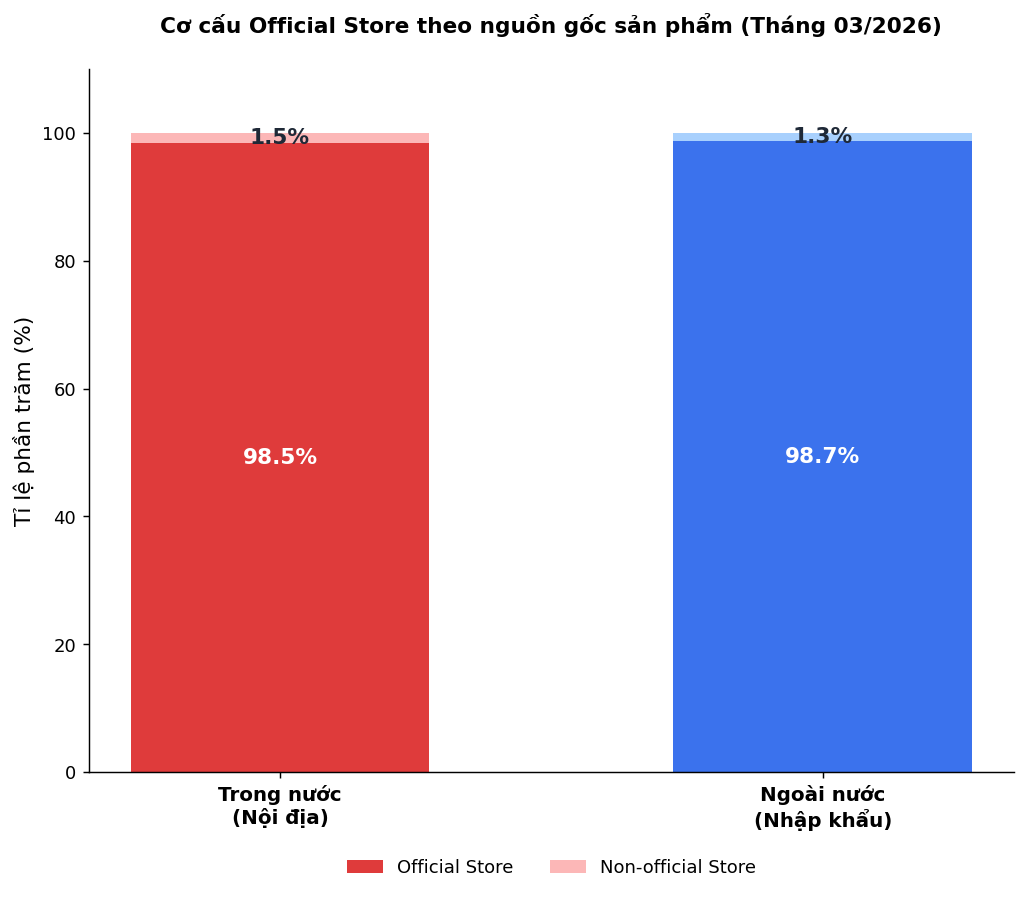

In [ ]:
# 1. CHUẨN BỊ DỮ LIỆU

# Đếm số lượng theo nhóm xuất xứ và trạng thái official
official_counts = df.groupby(['origin_class', 'is_official_store']).size().unstack(fill_value=0)

# Tính tỉ lệ phần trăm (%) trên tổng 100% của mỗi nhóm
official_summary = official_counts.div(official_counts.sum(axis=1), axis=0) * 100
official_summary.columns = ['rate_non', 'rate_official']

# Danh sách dữ liệu để vẽ
groups    = ['Trong nước', 'Ngoài nước']
rates_off = [official_summary.loc[g, 'rate_official'] for g in groups]
rates_non = [official_summary.loc[g, 'rate_non'] for g in groups]
labels    = ['Trong nước\n(Nội địa)', 'Ngoài nước\n(Nhập khẩu)']

# 2. CẤU HÌNH MÀU SẮC & THÔNG SỐ
# Màu đậm cho Official, màu nhạt cho Non-Official (Đỏ cho Trong nước, Xanh cho Ngoài nước)
colors_off = ['#DC2626', '#2563EB'] 
colors_non = ['#FCA5A5', '#93C5FD'] 

# 3. VẼ BIỂU ĐỒ (TRỰC QUAN HÓA)
fig, ax = plt.subplots(figsize=(8, 7))

x = np.arange(len(groups))
width = 0.55

# Vẽ phần Official (nằm dưới)
b1 = ax.bar(x, rates_off, color=colors_off, label='Official Store', width=width, alpha=0.9)

# Vẽ phần Non-Official (xếp chồng lên trên)
b2 = ax.bar(x, rates_non, bottom=rates_off, color=colors_non, label='Non-official Store', width=width, alpha=0.8)

# Thêm nhãn số liệu trực tiếp vào các đoạn cột
for i, (off, non) in enumerate(zip(rates_off, rates_non)):
    # Nhãn cho Official
    ax.text(i, off/2, f'{off:.1f}%', ha='center', va='center', 
            color='white', fontweight='bold', fontsize=12)
    # Nhãn cho Non-Official
    ax.text(i, off + non/2, f'{non:.1f}%', ha='center', va='center', 
            color='#1F2937', fontweight='bold', fontsize=12)

# Tinh chỉnh trục và nhãn
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Tỉ lệ phần trăm (%)', fontsize=12)
ax.set_ylim(0, 110) # Tạo khoảng trống phía trên cho Legend

# Tiêu đề và chú thích
ax.set_title('Cơ cấu Official Store theo nguồn gốc sản phẩm (Tháng 03/2026)', 
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ xếp chồng về cơ cấu Official Store theo nguồn gốc sản phẩm, ta rút ra một số nhận xét sau:
- Tỉ lệ Official Store cực kỳ cao ở cả hai nhóm — Hàng trong nước đạt **98,5%** và hàng ngoài nước đạt **98,7%**, chênh lệch chỉ **0,2 điểm phần trăm**. Hàng ngoại vẫn nhỉnh hơn một chút (0.2%). Điều này cho thấy các thương hiệu ngoại vẫn duy trì một kỷ luật thép trong việc kiểm soát kênh phân phối độc quyền. Tuy nhiên, khoảng cách này là không đáng kể, cho thấy lợi thế về uy tín của hàng ngoại đang dần bị xóa nhòa bởi sự nỗ lực chuyên nghiệp hóa của các thương hiệu Việt. Kết quả này cho thấy hệ sinh thái Tiki đã được chuẩn hóa mạnh mẽ: phần lớn nhà bán hàng — bất kể xuất xứ sản phẩm — đều hoạt động thông qua kênh chính hãng. 

- Không có sự phân hóa về "uy tín" giữa nội và ngoại xét theo tiêu chí Official Store. Đây là phát hiện quan trọng: giả thuyết "hàng ngoại được đầu tư kênh phân phối bài bản hơn" không được dữ liệu tháng 3/2026 xác nhận — cả hai đều tiếp cận Tiki qua Official Store với tỉ lệ gần như đồng đều.

- Con số 98.5% là một lời khẳng định đanh thép: Mỹ phẩm nội địa Việt không còn là những đơn vị làm ăn nhỏ lẻ mà đã hoàn toàn bắt kịp các tập đoàn quốc tế trong việc chuẩn hóa gian hàng và minh bạch hóa nguồn gốc. 


#### Biểu đồ cột nhóm về lượt bán trung bình Official vs Non-Official Store:
Biểu đồ thể hiện hiệu quả (dựa trên lượt bán trung bình) giữa các sản phẩm từ gian hàng official và non-official, từ đó thấy rõ được tầm quan trong của Official Store, hay nói rộng hơn là độ uy tín của thương hiệu.

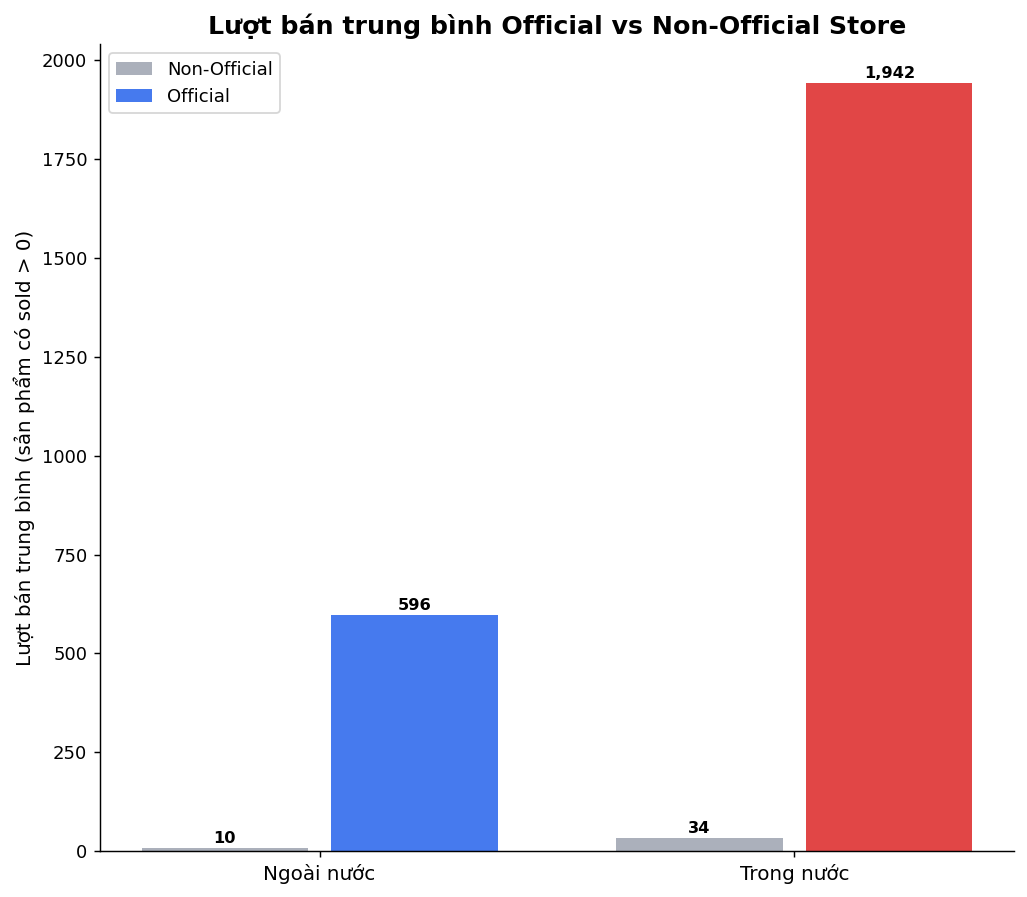

In [ ]:
fig, ax2 = plt.subplots(figsize=(8, 7))
df_has_sold = df[df['sold_count'] > 0]
eff = df_has_sold.groupby(['origin_class', 'is_official_store'])['sold_count'].mean().unstack()
eff.columns = ['Non-Official', 'Official']
eff_plot = eff.reset_index()

x2   = np.arange(len(eff_plot))
b_no = ax2.bar(x2 - 0.2, eff_plot['Non-Official'], 0.35, color='#9CA3AF', alpha=0.85, label='Non-Official')
b_of = ax2.bar(x2 + 0.2, eff_plot['Official'],     0.35,
               color=[C_DOMESTIC, C_IMPORT], alpha=0.85, label='Official')

for bar in [*b_no, *b_of]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(eff_plot['origin_class'], fontsize=11)
ax2.set_ylabel('Lượt bán trung bình (sản phẩm có sold > 0)')
ax2.set_title('Lượt bán trung bình Official vs Non-Official Store', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ cột nhóm về lượt bán trung bình Official vs Non-Official Stor, ta rút ra một số nhận xét sau:
- Sức mạnh áp đảo của nhãn "Official": Khoảng cách về lượng bán là một con số "biết nói". Tại nhóm Trong nước, gian hàng Official bán được trung bình 443.3 sản phẩm, trong khi gian hàng thường chỉ vỏn vẹn 3.3 sản phẩm. Tương tự với hàng ngoại, con số này là 46.8 so với 0.3.

- Người dùng có xu hướng bỏ qua hoàn toàn các gian hàng không có bảo chứng khi mua mỹ phẩm — một mặt hàng nhạy cảm trực tiếp đến sức khỏe. Từ đó thấy rõ tầm quan trọng của Gian hàng chính hãng.

**Kết luận:** 

Từ hai biểu đồ trên ta thấy rõ uy tín là chìa khóa quan trọng, biểu đồ cột nhóm đã chứng minh rõ ràng rằng uy tín thương hiệu tỉ lệ thuận với hiệu quả bán hàng. Một gian hàng chính hãng có khả năng vận hành hiệu quả gấp hàng chục, hàng trăm lần gian hàng thường. Các thương hiệu đã làm rất tốt việc tạo dựng sự chuyên nghiệp và gầy dựng niềm tin cho khách hàng trên sàn Tiki, khi mà hầu hết gian hàng đều nỗ lực để trở thành gian hàng chính hãng. 

Trên "đấu trường" Tiki, mỹ phẩm Việt không hề thua kém hàng ngoại về độ uy tín và sự chuyên nghiệp.  Tỉ lệ Official Store không phải yếu tố phân biệt giữa thương hiệu nội và ngoại. Thay vào đó, Tiki đã tạo ra một sân chơi bình đẳng về mặt kênh phân phối, khi đó, điểm cạnh tranh nằm ở chất lượng sản phẩm, chiến lược giá và khả năng thu hút lượt bán. 

## **2.2. Mục tiêu 2:** Dựa trên dữ liệu tháng 3/2026, xác định hồ sơ Top 10 thương hiệu nội địa và quốc tế có doanh thu ước tính cao nhất nhằm nhận diện những đơn vị đang dẫn dắt thị phần mỹ phẩm.



In [ ]:
# --- CODE MỤC TIÊU 2 ---
import plotly.express as px

# 1. Chuẩn bị dữ liệu Top 10
top_10_domestic = df[df['origin_class'] == 'Trong nước'].groupby('brand_name')['estimated_revenue'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_foreign = df[df['origin_class'] == 'Ngoài nước'].groupby('brand_name')['estimated_revenue'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Vẽ biểu đồ Bar Chart (Sử dụng Plotly cho tính tương tác)
fig2_1 = px.bar(pd.concat([top_10_domestic.assign(Type='Nội địa'), top_10_foreign.assign(Type='Quốc tế')]), 
             x='estimated_revenue', y='brand_name', color='Type', barmode='group',
             title='Top 10 Thương hiệu dẫn dắt Doanh thu (Nội địa vs Quốc tế)',
             labels={'estimated_revenue':'Doanh thu ước tính (VNĐ)', 'brand_name':'Thương hiệu'},
             color_discrete_map={'Nội địa':'#DC2626', 'Quốc tế':'#2563EB'})
fig2_1.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
fig2_1.show()

## **2.3. Mục tiêu 3:** Phân tích tỷ trọng số sản phẩm và doanh thu ước tính theo quốc gia xuất xứ (Hàn, Nhật, Mỹ, Pháp...) trong nhóm hàng nhập khẩu quốc tế (tháng 3/2026) để xác định Top 3 quốc gia cạnh tranh trực tiếp lớn nhất với mỹ phẩm Việt Nam.

In [ ]:
# --- CODE MỤC TIÊU 3 ---
# 1. Tính toán dữ liệu quốc gia
country_data = df[df['origin_class'] == 'Ngoài nước'].groupby('origin_normalized').agg(
    total_rev=('estimated_revenue', 'sum'),
    prod_count=('product_id', 'count')
).reset_index().sort_values('total_rev', ascending=False)

# 2. Vẽ Treemap
fig3 = px.treemap(df[df['origin_class'] == 'Ngoài nước'], 
                  path=['origin_normalized', 'brand_name'], 
                  values='estimated_revenue',
                  title='Bản đồ ảnh hưởng của Mỹ phẩm Quốc tế trên Tiki',
                  color='estimated_revenue',
                  color_continuous_scale='RdBu')
fig3.show()